In [21]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [23]:
df = pd.read_csv("titanic_toy.csv")

In [24]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [26]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [27]:
X = df.drop(columns=['Survived'])
y= df['Survived']

In [28]:
X_train, X_test , y_train , y_test = train_test_split(X,y,test_size=0.2 , random_state=2)

In [29]:
X_train.shape , X_test.shape

((712, 3), (179, 3))

In [30]:
X_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [31]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_test['Fare'].median()

In [32]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_age)

In [33]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
738,NaN,7.8958,0,28.75,29.785904,7.8958,7.8958
798,30.0,7.2292,0,30.00,30.000000,7.2292,7.2292
301,NaN,23.2500,2,28.75,29.785904,23.2500,23.2500
876,20.0,9.8458,0,20.00,20.000000,9.8458,9.8458
178,30.0,13.0000,0,30.00,30.000000,13.0000,13.0000


In [34]:
print("Original Age Variable variance: " ,X_train['Age'].var())
print("Variance after age median imputer : " , X_train['Age_median'].var())
print("Variance after age mean imputer : " , X_train['Age_mean'].var())

print("Original Fare Variable variance: " ,X_train['Fare'].var())
print("Variance after Fare median imputer : " , X_train['Fare_median'].var())
print("Variance after Fare mean imputer : " , X_train['Fare_mean'].var())


Original Age Variable variance:  204.3495133904614
Variance after age median imputer :  161.9895663346054
Variance after age mean imputer :  161.81262452718673
Original Fare Variable variance:  2448.197913706318
Variance after Fare median imputer :  2341.0882322100842
Variance after Fare mean imputer :  2324.623996772905


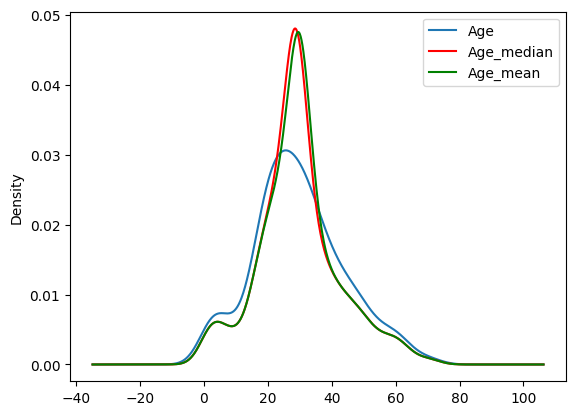

In [35]:
fig = plt.figure()
ax = fig.add_subplot(111)

#original variable distribution
X_train['Age'].plot(kind = 'kde', ax=ax)

#variable imputed with the median
X_train['Age_median'].plot(kind='kde' , ax=ax , color='red')

#variable imputed with the mean
X_train['Age_mean'].plot(kind='kde',ax = ax , color='green')

#add legends
lines ,labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

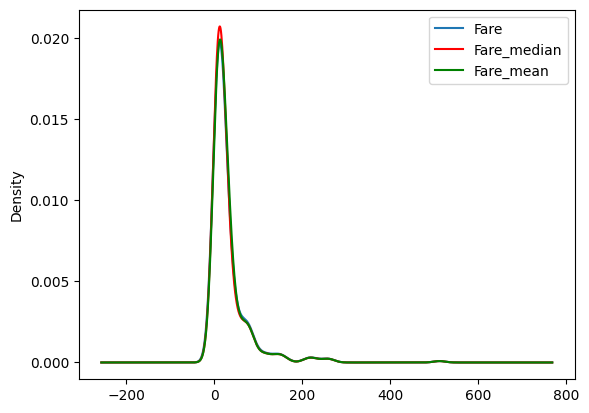

In [36]:
fig = plt.figure()
ax = fig.add_subplot(111)

#original variable distribution
X_train['Fare'].plot(kind = 'kde', ax=ax)

#variable imputed with the median
X_train['Fare_median'].plot(kind='kde' , ax=ax , color='red')

#variable imputed with the mean
X_train['Fare_mean'].plot(kind='kde',ax = ax , color='green')

#add legends
lines ,labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [37]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,64.802911,66.383530
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,16.479132,16.399278
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,53.507938,54.793876
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,51.313698,52.565299
Fare_median,64.802911,2448.197914,16.479132,53.507938,51.313698,2341.088232,2326.787069
Fare_mean,66.383530,2448.197914,16.399278,54.793876,52.565299,2326.787069,2324.623997


In [39]:
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.087261,0.089754
Fare,0.092644,1.000000,0.208268,0.091757,0.088069,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.242883,-0.244610,0.205933,0.205660
Age_median,1.000000,0.091757,-0.242883,1.000000,0.999454,0.086889,0.089292
Age_mean,1.000000,0.088069,-0.244610,0.999454,1.000000,0.083372,0.085707
Fare_median,0.087261,1.000000,0.205933,0.086889,0.083372,1.000000,0.997405
Fare_mean,0.089754,1.000000,0.205660,0.089292,0.085707,0.997405,1.000000


<Axes: >

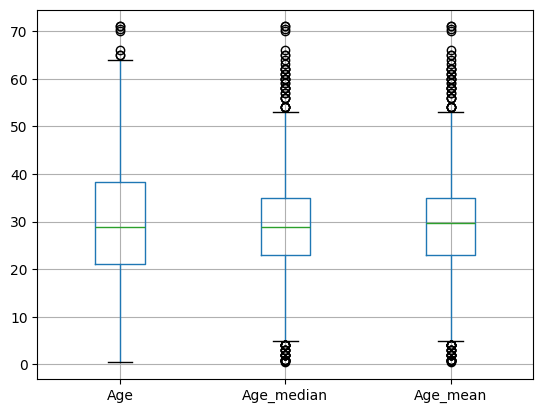

In [40]:
X_train[['Age','Age_median','Age_mean']].boxplot()

<Axes: >

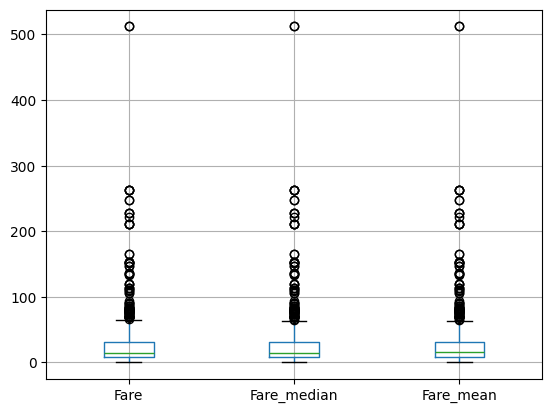

In [42]:
X_train[['Fare','Fare_median','Fare_mean']].boxplot()

In [43]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=2)

In [44]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [45]:
trf = ColumnTransformer([
    ('imputer1' , imputer1 , ['Age']),
    ('imputer2' , imputer2 , ['Fare'])
], remainder = 'passthrough')

In [46]:
trf.fit(X_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [47]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [48]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [49]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [50]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]], shape=(712, 3))